In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# 1. LOAD AND EXPLORE THE DATA
# Read the dataset using pandas.
# Check for missing values and handle them.
# Understand the data distribution and class balance.

data = pd.read_csv('/content/gdrive/My Drive/Cardiovascular_Disease_Dataset.csv')
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [4]:
print(data)

     patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0       103368   53       1          2        171                0   
1       119250   40       1          0         94              229   
2       119372   49       1          2        133              142   
3       132514   43       1          0        138              295   
4       146211   31       1          1        199                0   
..         ...  ...     ...        ...        ...              ...   
995    9949544   48       1          2        139              349   
996    9953423   47       1          3        143              258   
997    9965859   69       1          0        156              434   
998    9988507   45       1          1        186              417   
999    9990855   25       1          0        158              270   

     fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                    0                1           147              0      5.3 

In [5]:
# Check for missing values
print(data.isnull().sum())
#as there is no missing values present, there's no need to handle them

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [6]:
# Understanding the data distribution and class balance.
print(data.describe()) # Summary statistics for numerical features

          patientid         age       gender    chestpain    restingBP  \
count  1.000000e+03  1000.00000  1000.000000  1000.000000  1000.000000   
mean   5.048704e+06    49.24200     0.765000     0.980000   151.747000   
std    2.895905e+06    17.86473     0.424211     0.953157    29.965228   
min    1.033680e+05    20.00000     0.000000     0.000000    94.000000   
25%    2.536440e+06    34.00000     1.000000     0.000000   129.000000   
50%    4.952508e+06    49.00000     1.000000     1.000000   147.000000   
75%    7.681877e+06    64.25000     1.000000     2.000000   181.000000   
max    9.990855e+06    80.00000     1.000000     3.000000   200.000000   

       serumcholestrol  fastingbloodsugar  restingrelectro  maxheartrate  \
count      1000.000000        1000.000000      1000.000000   1000.000000   
mean        311.447000           0.296000         0.748000    145.477000   
std         132.443801           0.456719         0.770123     34.190268   
min           0.000000       

In [7]:
# determine the datatype of all columns
data.dtypes

,0
patientid,int64
age,int64
gender,int64
chestpain,int64
restingBP,int64
serumcholestrol,int64
fastingbloodsugar,int64
restingrelectro,int64
maxheartrate,int64
exerciseangia,int64


In [8]:
# Class balance (for the target variable)
print(data['target'].value_counts())

target
1    580
0    420
Name: count, dtype: int64


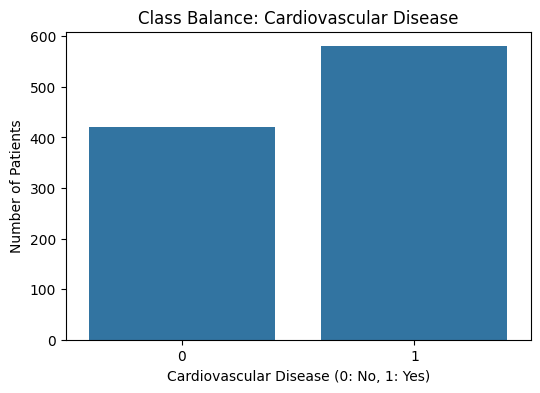

In [9]:
# Visualize class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Class Balance: Cardiovascular Disease')
plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
plt.ylabel('Number of Patients')
plt.show()

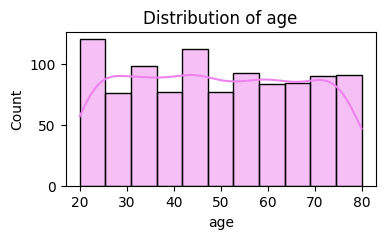

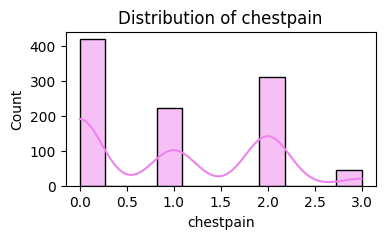

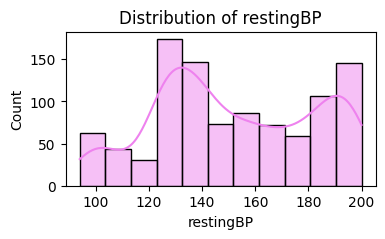

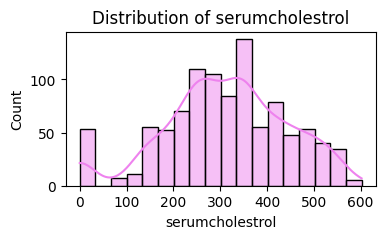

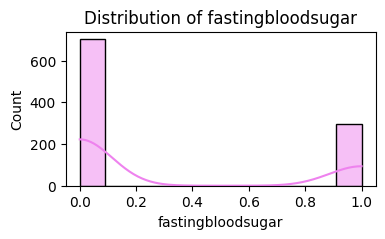

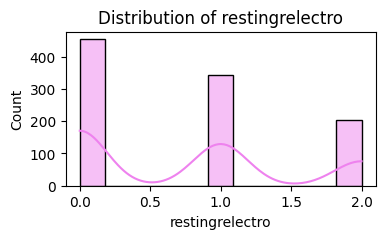

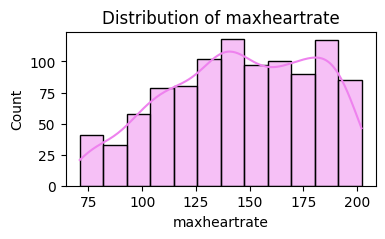

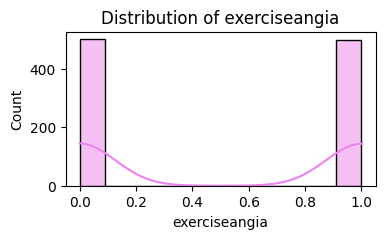

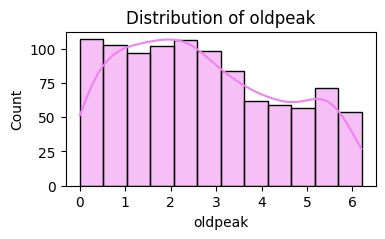

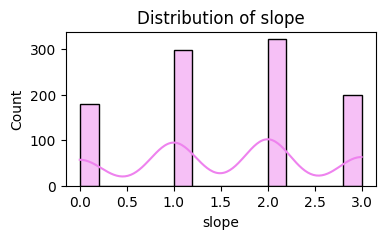

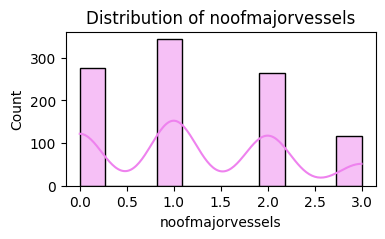

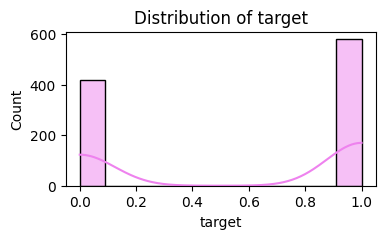

In [10]:
# Histograms for numerical features
numerical_features = ['age', 'chestpain','restingBP','serumcholestrol','fastingbloodsugar','restingrelectro',
                     'maxheartrate','exerciseangia','oldpeak', 'slope','noofmajorvessels','target']
for col in numerical_features:
    plt.figure(figsize=(4, 2))
    sns.histplot(data[col], kde=True,color='violet')
    plt.title(f'Distribution of {col}')
    plt.show()

In [11]:
# Outlier Detection and Handling
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Applying outlier removal to specific columns
for col in ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']:
    data = remove_outliers_iqr(data, col)

print(data.shape) #check the number of rows after outlier removal

(1000, 14)


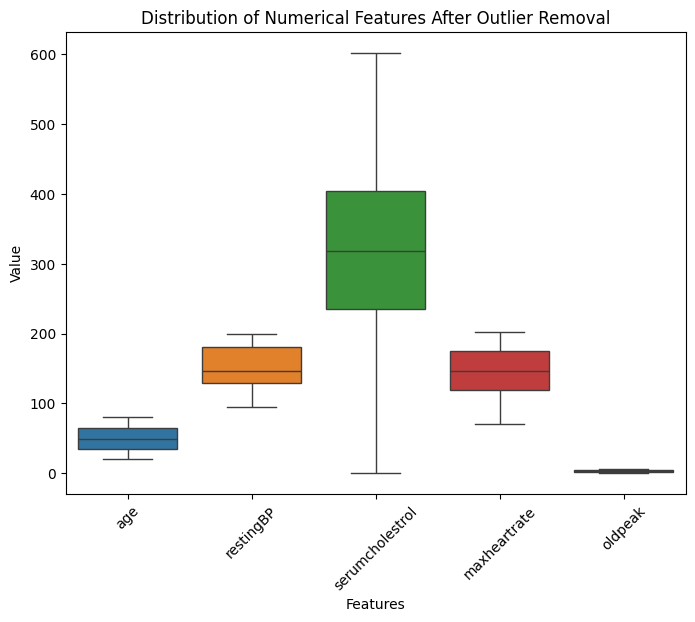

In [12]:
# Select the columns for boxplot visualization
columns_for_boxplot = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=data[columns_for_boxplot])
plt.title('Distribution of Numerical Features After Outlier Removal')
plt.ylabel('Value')
plt.xlabel('Features')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

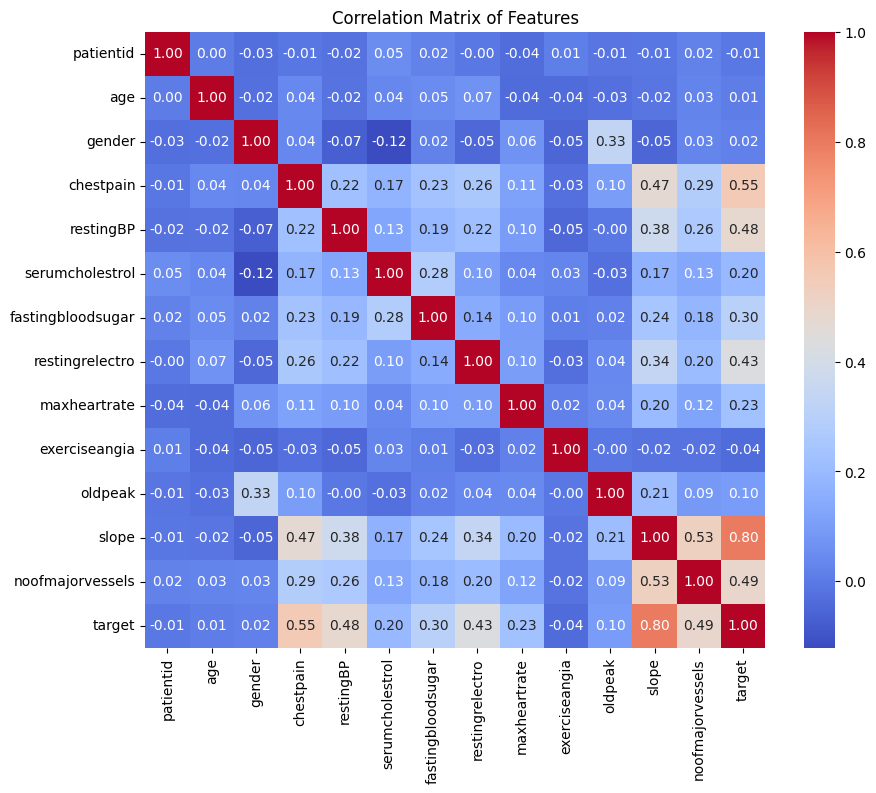

In [13]:
# Correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

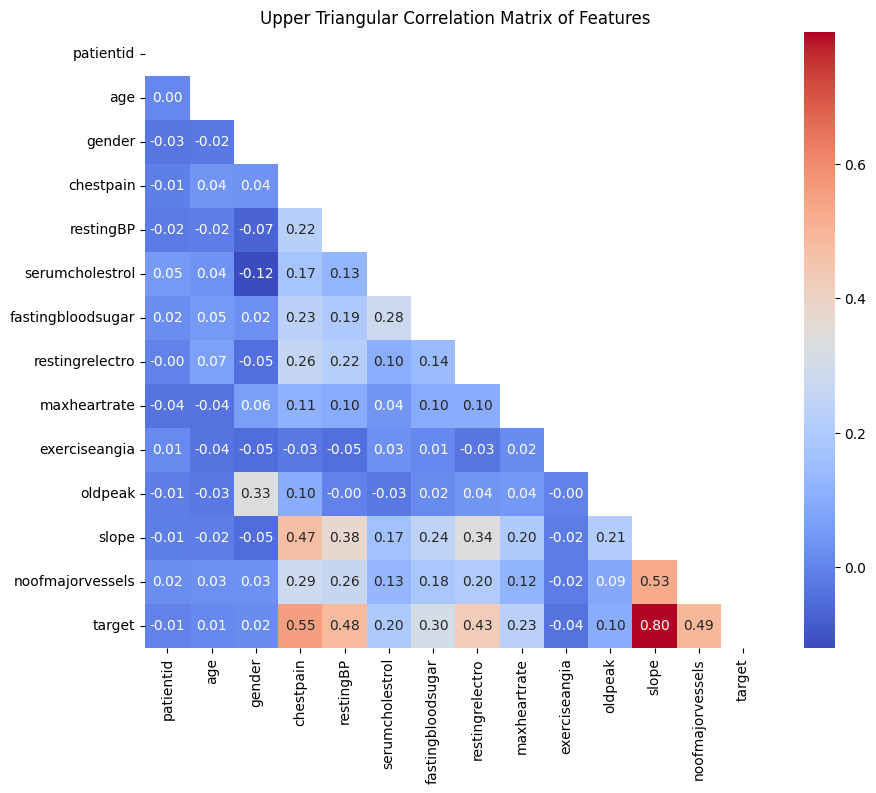

In [14]:
# Plotting the upper triangular heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Upper Triangular Correlation Matrix of Features')
plt.show()

In [15]:
# 2. PREPROCESS THE DATA
# Encode categorical variables (if any).
# Normalize or standardize numerical features if needed.
# Split the dataset into training and testing sets.

# Identify categorical columns (numerical but categorical in nature)
categorical_cols = [col for col in data.columns if data[col].nunique() < 5 and col != 'target']

# One-hot encode categorical features
if len(categorical_cols) > 0:
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    print("Categorical features encoded successfully")
else:
    print("No categorical features found in the dataset.")

Categorical features encoded successfully


In [16]:
#Standardize the numericals features if needed

from sklearn.preprocessing import StandardScaler

# Select numerical features to scale (excluding the target variable)
numerical_cols = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

In [17]:
# Split the dataset into training and testing sets.

from sklearn.model_selection import train_test_split
X = data.drop('target', axis=1)
y = data['target']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #random_state for reproducibility

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (800, 20) (800,)
Testing set shape: (200, 20) (200,)


In [18]:
# 3. TRAIN THE NAIVE BAYES MODEL
#choose GaussianNB for the continuous values and BernoulliNB for binary values (if present) and fit the model on the training data

from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Identify binary columns
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]

# Create a combined model
if binary_cols:
    model = {col: BernoulliNB() for col in binary_cols}
    model['gaussian'] = GaussianNB()
else:
    model = GaussianNB()


if binary_cols:
    # Fit binary columns with BernoulliNB
    for col in binary_cols:
        model[col].fit(X_train[[col]], y_train)
    # Fit other columns with GaussianNB
    remaining_cols = [col for col in X_train.columns if col not in binary_cols]
    model['gaussian'].fit(X_train[remaining_cols], y_train)

else:
    model.fit(X_train, y_train)

In [19]:
# 4. EVALUATE THE MODEL
# Predict on the test data.
# Compute accuracy, precision, recall, and F1-score.
# Use a confusion matrix to analyze predictions.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

if binary_cols:
    # Predict using the combined model
    y_pred_prob = {}
    for col in binary_cols:
        y_pred_prob[col] = model[col].predict_proba(X_test[[col]])[:, 1]
    y_pred_prob['gaussian'] = model['gaussian'].predict_proba(X_test[[col for col in X_test.columns if col not in binary_cols]])[:, 1]

    # Combine probabilities (simple averaging)
    combined_prob = np.mean(np.array([y_pred_prob[col] for col in y_pred_prob]),axis=0)
    y_pred = (combined_prob >= 0.5).astype(int)

else:
    y_pred = model.predict(X_test)

In [20]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.5850
Precision: 0.5850
Recall: 1.0000
F1-score: 0.7382


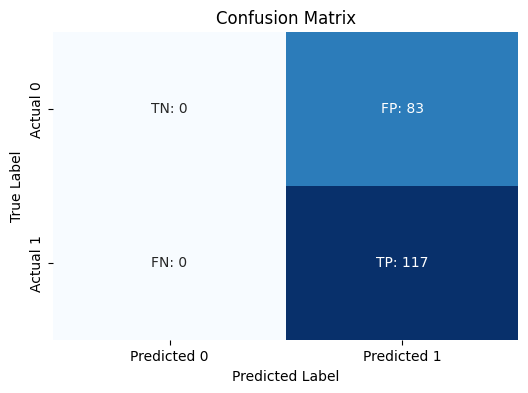

In [21]:
#Confusion Matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Custom labels for the matrix
group_labels = [
    f'TN: {cm[0, 0]}', f'FP: {cm[0, 1]}',
    f'FN: {cm[1, 0]}', f'TP: {cm[1, 1]}'
]
group_labels = [label for label in group_labels]

# Reshape labels to match matrix dimensions
cm_labels = [[group_labels[0], group_labels[1]],
             [group_labels[2], group_labels[3]]]

# Plot confusion matrix with explicit labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [22]:
# 5.OPTIMIZE THE MODEL
# Tune hyperparameters.
# Try feature selection or engineering.
# Experiment with different preprocessing techniques.

from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.naive_bayes import GaussianNB


# Define the parameter grid for hyperparameter tuning
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

# Initialize the model
model = GaussianNB()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy (tuned): {accuracy:.4f}")
print(f"Precision (tuned): {precision:.4f}")
print(f"Recall (tuned): {recall:.4f}")
print(f"F1-score (tuned): {f1:.4f}")

Best Hyperparameters: {'var_smoothing': np.float64(1.0)}
Accuracy (tuned): 0.5850
Precision (tuned): 0.5850
Recall (tuned): 1.0000
F1-score (tuned): 0.7382


In [23]:
# Saving the model
joblib.dump(model, 'Naive_Bayes_model.pkl')

['Naive_Bayes_model.pkl']

## Key Observations

* The model performed well in detecting cardiovascular disease cases but may show bias if the dataset is imbalanced.
* If false negatives (FN) are high, additional feature engineering or an alternative model (e.g., Logistic Regression, Random Forest) may be needed.
* The Naive Bayes assumption of feature independence may not fully hold for medical data, which could affect predictive power.
* Naive Bayes provided a quick, interpretable model for cardiovascular disease classification.
* However, if precision or recall is low, further tuning or different models should be considered.